In [16]:
from statistics import correlation

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.core.pylabtools import figsize

df = pd.read_csv("../data/Premier_League/PremierLeague_Match_Data_Ready_For_ML.csv", parse_dates=['Date'])

print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 9701 entries, 0 to 9700
Data columns (total 81 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Div                                9701 non-null   str           
 1   Date                               9701 non-null   datetime64[us]
 2   HomeTeam                           9701 non-null   str           
 3   AwayTeam                           9701 non-null   str           
 4   Referee                            9701 non-null   str           
 5   Season                             9701 non-null   str           
 6   Target                             9701 non-null   int64         
 7   Home_DaysOfRest                    9701 non-null   float64       
 8   Away_DaysOfRest                    9701 non-null   float64       
 9   Home_Last5_HomePts                 9701 non-null   float64       
 10  Home_Last5_GF                      9701 non-nul

# Distribution of Match Outcomes
In this first visualization, I'm creating a simple bar chart to show the distribution of match outcomes (Home Win, Draw, Away Win). This gives me a baseline understanding of how frequent each outcome is in the Premier League.

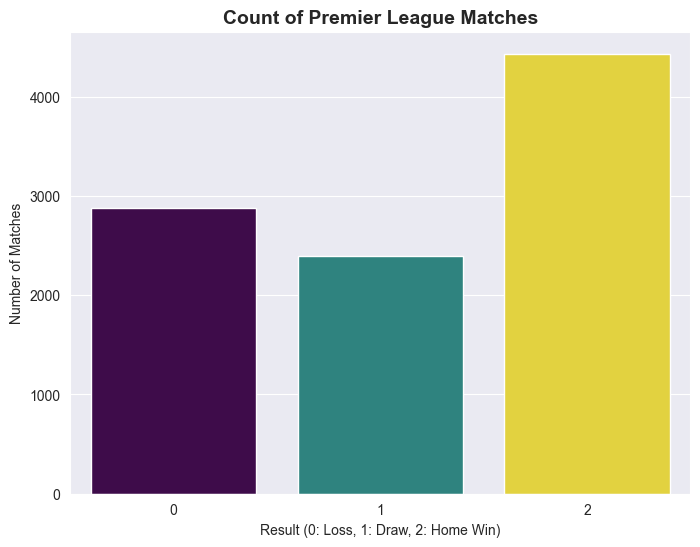

In [17]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='Target',hue='Target', palette='viridis', legend=False)
plt.title('Count of Premier League Matches', fontsize=14, fontweight='bold')
plt.xlabel('Result (0: Loss, 1: Draw, 2: Home Win)')
plt.ylabel('Number of Matches')
plt.show()


# Impact of Home Team ELO on Match Outcome
Here, I'm using a box plot to visualize the relationship between the home team's ELO rating and the final match result. This helps me to see if a higher ELO rating for the home team generally corresponds to a higher likelihood of winning.

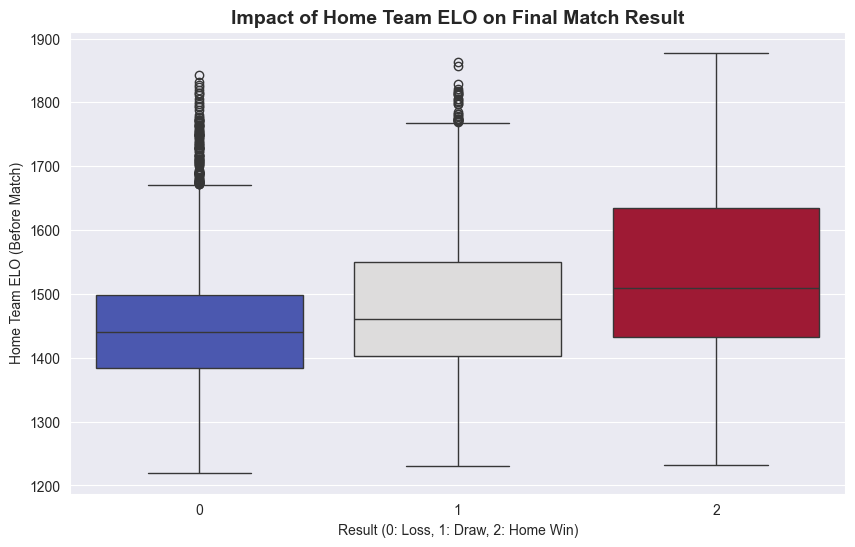

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Target', y='Home_ELO',hue='Target', palette='coolwarm', legend=False)
plt.title('Impact of Home Team ELO on Final Match Result', fontsize=14, fontweight='bold')
plt.xlabel('Result (0: Loss, 1: Draw, 2: Home Win)')
plt.ylabel('Home Team ELO (Before Match)')
plt.show()

# Top Features Correlated with Home Win
This bar chart displays the top 22 features that are most correlated (both positively and negatively) with a home team win. This is a quick way for me to identify which factors might be the most predictive of the match outcome.

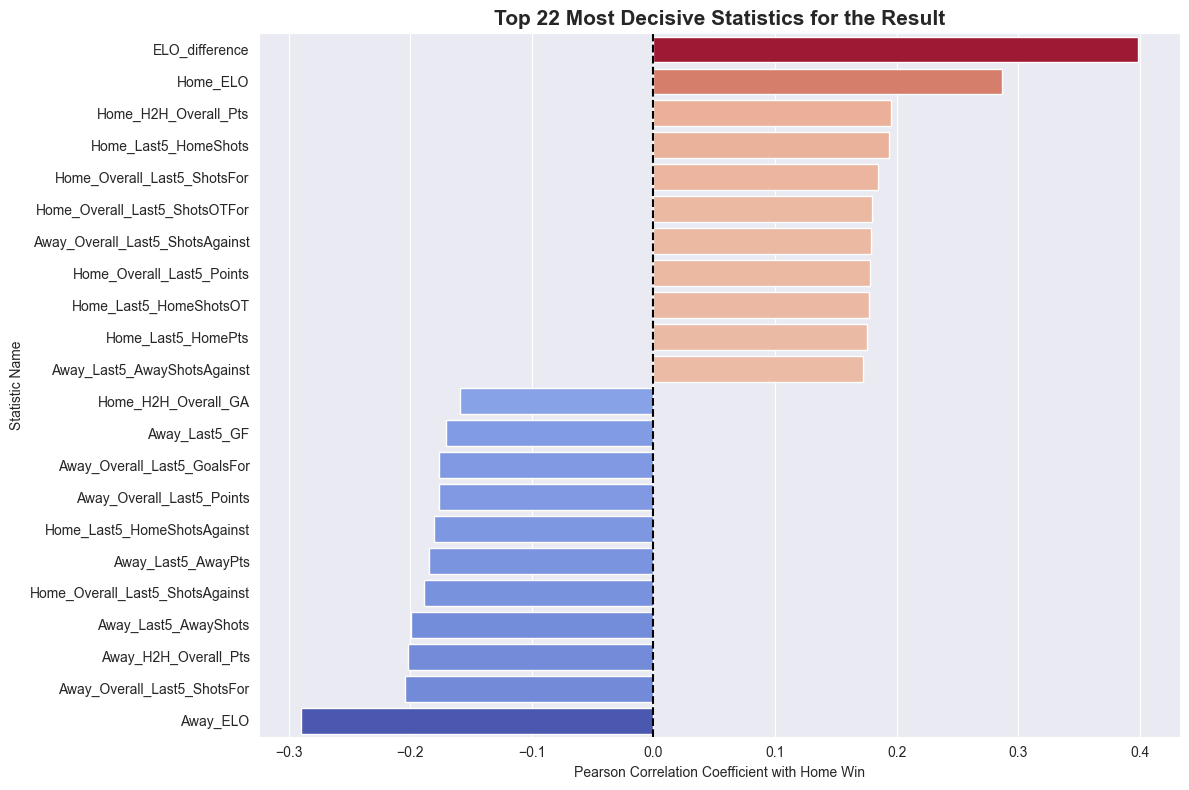

In [19]:
numeric_cols = df.select_dtypes(include=['float64','int64'])

corr_with_target = numeric_cols.corr()['Target'].drop('Target').sort_values(ascending=False)

top_features= pd.concat([corr_with_target.head(11), corr_with_target.tail(11)])
plt.figure(figsize=(12,8))

sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.values, palette='coolwarm', legend=False)
plt.title('Top 22 Most Decisive Statistics for the Result', fontsize=15, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient with Home Win')
plt.ylabel('Statistic Name')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

# Impact of Rest Advantage on Home Win Percentage
To investigate the effect of fatigue, I've created a "Rest Advantage" feature and categorized it into buckets. This bar chart shows the home win percentage for each of these buckets, allowing me to see how a significant rest advantage (or disadvantage) affects the home team's chances of winning.

In [20]:
df['Rest_Advantage']= df['Home_DaysOfRest'] - df['Away_DaysOfRest']

In [21]:
def categorize_rest(diff):
    if diff <= -3: return "1. Very Tired (<= -3 days)"
    elif diff in [-2, -1]: return "2. Slightly Tired (-1, -2 days)"
    elif diff == 0: return "3. Equal Rest (0 days)"
    elif diff in [1,2]: return "4. Slightly Rested (+1, +2 days)"
    else: return "5. Very Rested (>= +3 days)"

In [22]:
df['Rest_Bucket'] = df['Rest_Advantage'].apply(categorize_rest)
rest_stats = df.groupby('Rest_Bucket')['Target'].apply(lambda x: (x== 2).mean() * 100).reset_index()
rest_stats.rename(columns={'Target':'WinPercentage'}, inplace=True)
rest_stats = rest_stats.sort_values(by='Rest_Bucket', ascending=False)

Text(0, 0.5, 'Percentage of Matches Won (%)')

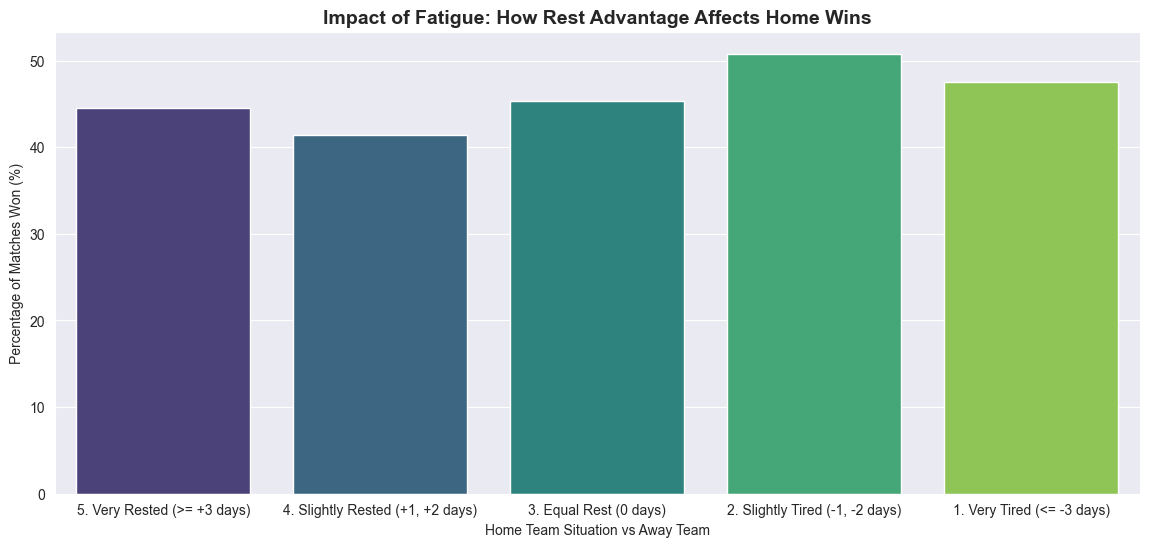

In [23]:
plt.figure(figsize=(14,6))
sns.barplot(data=rest_stats, x='Rest_Bucket',y='WinPercentage',hue='Rest_Bucket', palette='viridis', legend=False)
plt.title('Impact of Fatigue: How Rest Advantage Affects Home Wins', fontsize=14, fontweight='bold')
plt.xlabel('Home Team Situation vs Away Team')
plt.ylabel('Percentage of Matches Won (%)')

# Correlation Heatmap of Top Features
This heatmap shows the correlation between the top 30 most important features. This is useful for me to identify multicollinearity, which is when two or more features are highly correlated with each other. This can be a problem for some machine learning models.

In [24]:
import numpy as np

numeric_cols = df.select_dtypes(include= ['float64', 'int64'])
correlations_with_target = numeric_cols.corr()['Target'].abs().drop('Target').sort_values(ascending=False)
top_15_features = correlations_with_target.head(30).index.tolist()


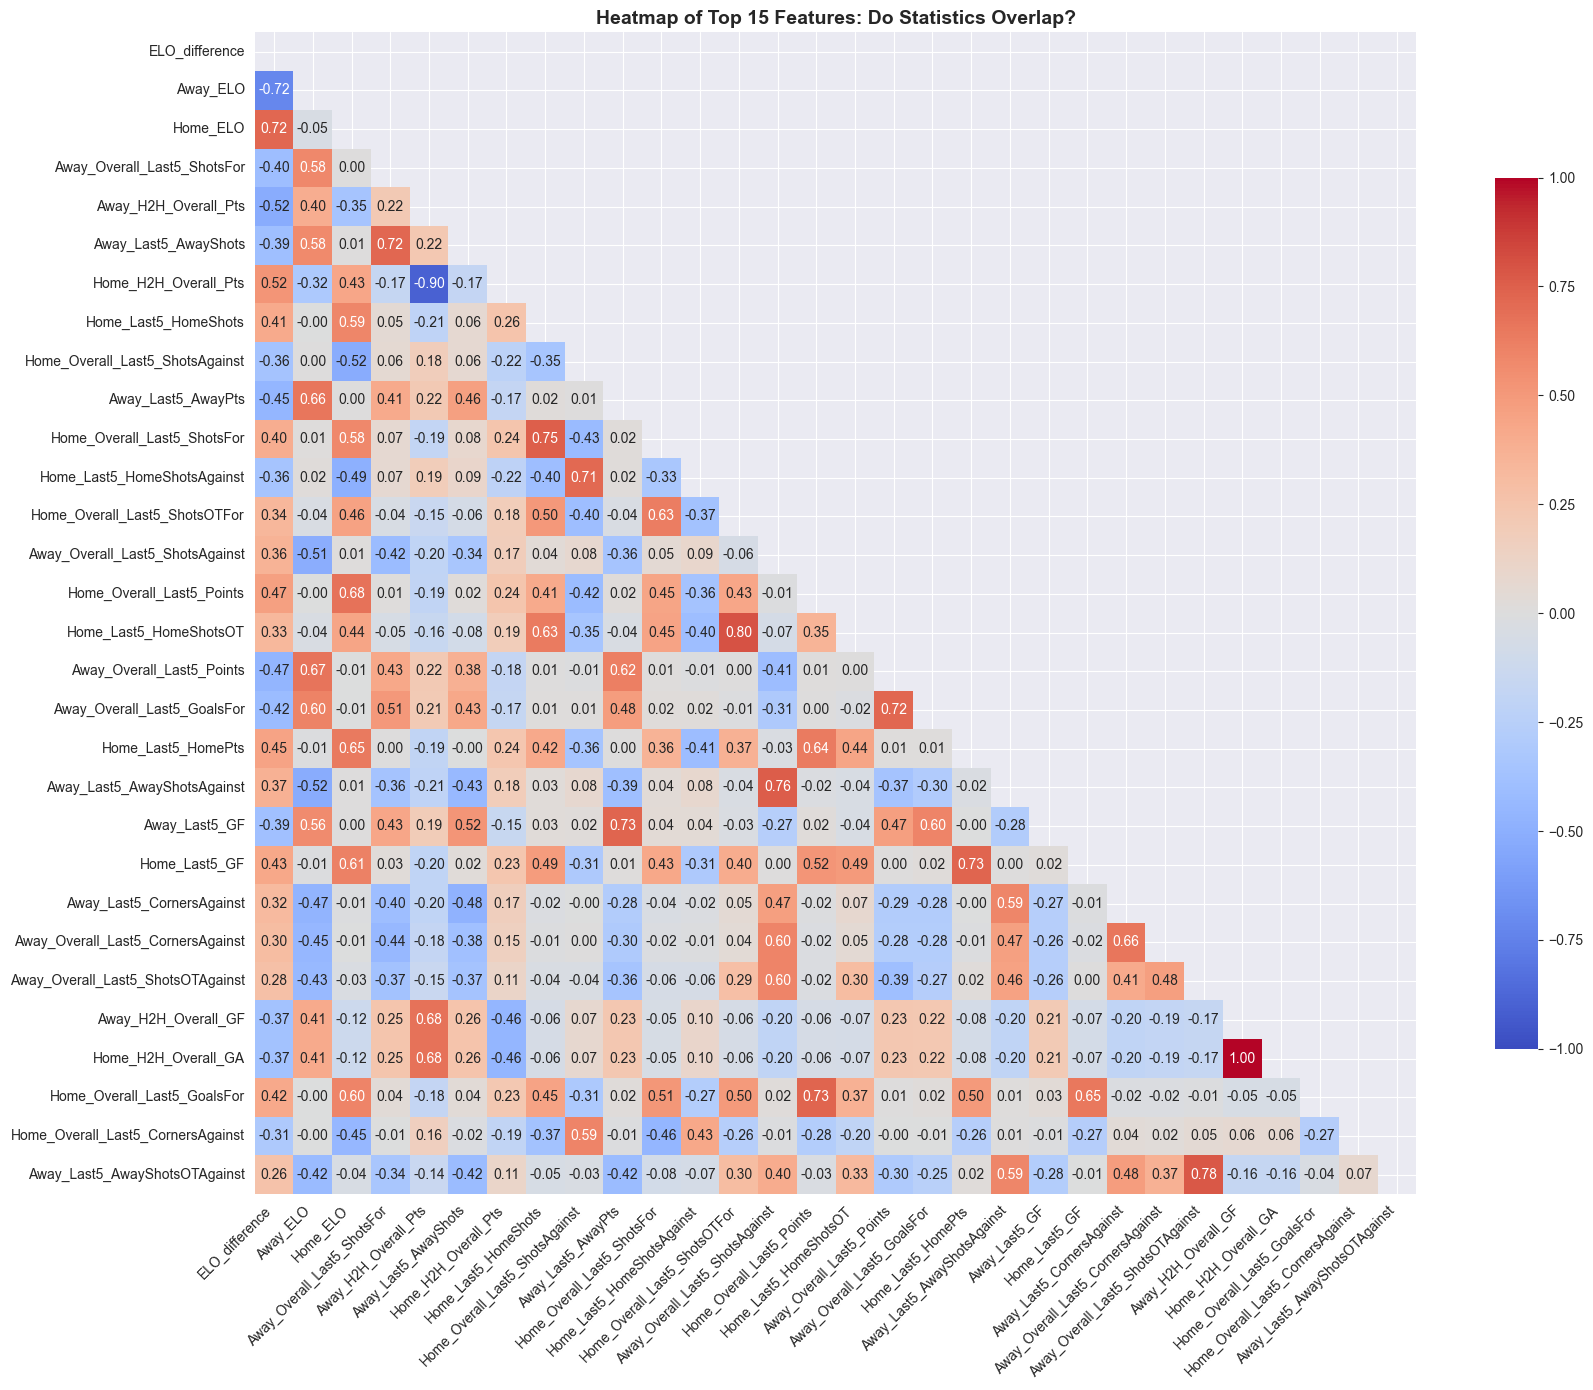

In [25]:
corr_matrix = df[top_15_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(18,14))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True, cbar_kws={'shrink': .75})

plt.title('Heatmap of Top 15 Features: Do Statistics Overlap?', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Evolution of Home Advantage Over Seasons
*TODO: DELETE H2H AWAY*

This line chart tracks the percentage of home wins, draws, and away wins over all the seasons in the dataset. This allows me to see if the "home-field advantage" has changed over time. I've also highlighted the 2020/2021 "COVID season" to see what effect empty stadiums might have had.

In [26]:
season_stats = df.groupby('Season')['Target'].value_counts(normalize=True).unstack() * 100

season_stats.rename(columns = {
    0: 'Away Win',
    1: 'Draw',
    2: 'Home Win'
}, inplace=True)

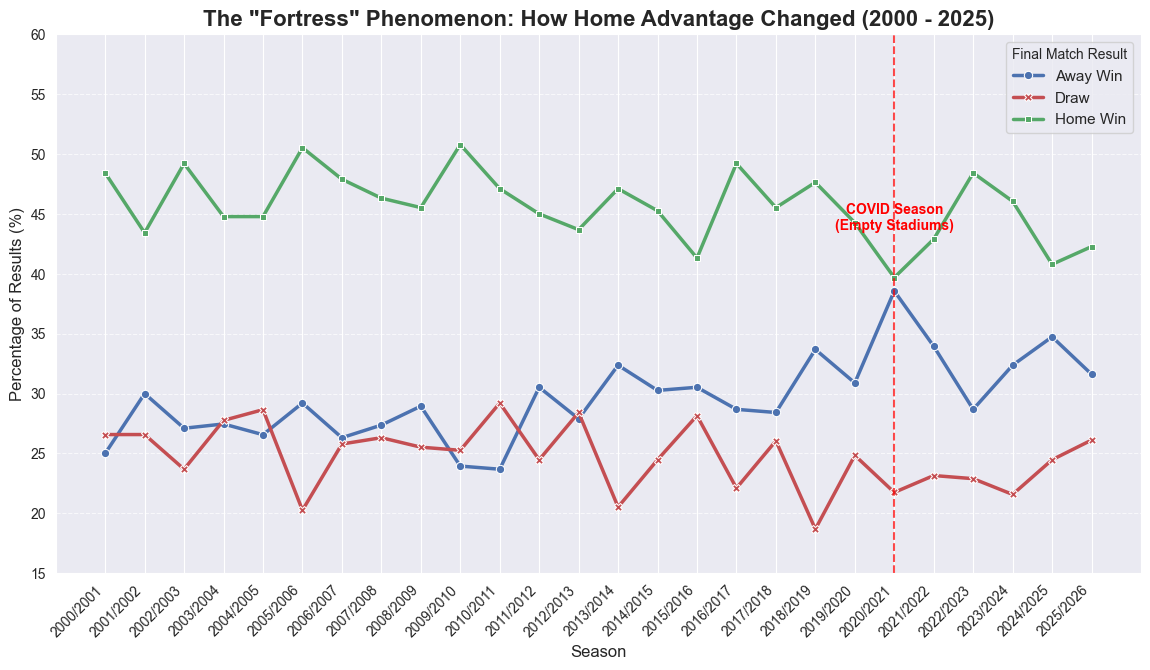

In [27]:
plt.figure(figsize=(14,7))
sns.lineplot(data=season_stats,markers=True,dashes=False,linewidth=2.5,palette=['#4c72b0', '#c44e52', '#55a868'])

plt.title('The "Fortress" Phenomenon: How Home Advantage Changed (2000 - 2025)',fontsize=16, fontweight='bold')
plt.xlabel('Season',fontsize=12)
plt.ylabel('Percentage of Results (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
if '2020/2021' in season_stats.index:
    plt.axvline(x='2020/2021', color='red', linestyle='--', alpha=0.7)
    y_val = season_stats.loc['2020/2021', 'Home Win']
    plt.text('2020/2021', y_val + 4, 'COVID Season\n(Empty Stadiums)',color = 'red', ha='center', fontweight='bold')

plt.legend(title='Final Match Result', fontsize=11)
plt.ylim(15,60)
plt.grid(axis='y', linestyle='--',alpha=0.7)
plt.show()

# ELO Rating Evolution of Top Teams
This line chart shows the smoothed ELO rating of five of the biggest Premier League clubs over time. This gives me a sense of their relative strength and how their dominance has evolved over the years.

In [28]:
teams_to_plot = ['Man United', 'Man City', 'Arsenal', 'Chelsea', 'Liverpool']
elo_data = df[df['HomeTeam'].isin(teams_to_plot)][['Date', 'HomeTeam','Home_ELO']].copy()
elo_data.rename(columns={'HomeTeam':'Team', 'Home_ELO':'ELO'}, inplace=True)

elo_data['Smoothed_ELO']=elo_data.groupby('Team')['ELO'].transform(lambda x: x.rolling(10,min_periods=1).mean())

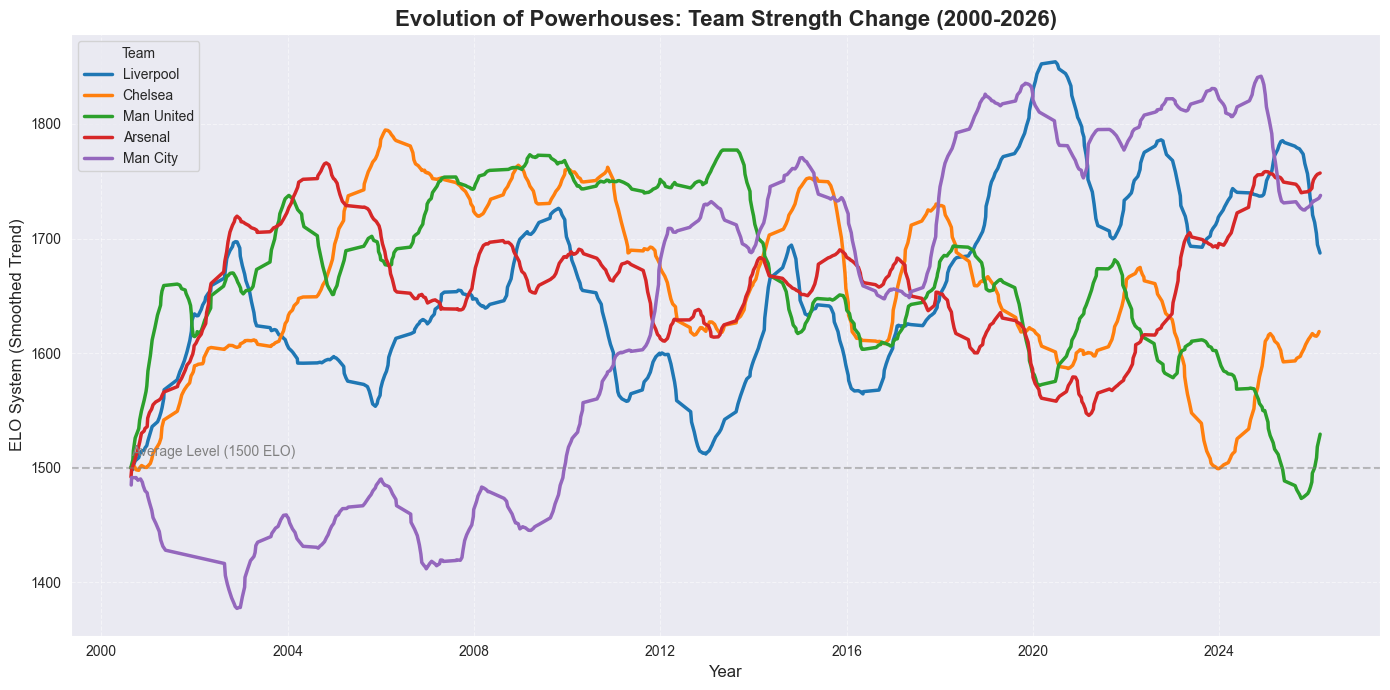

In [29]:
plt.figure(figsize=(14,7))
sns.lineplot(data=elo_data, x='Date', y='Smoothed_ELO',hue='Team',linewidth=2.5,palette='tab10')
plt.title('Evolution of Powerhouses: Team Strength Change (2000-2026)',fontsize=16, fontweight='bold')
plt.xlabel('Year',fontsize=12)
plt.ylabel('ELO System (Smoothed Trend)', fontsize=12)

plt.axhline(y=1500,color='gray',linestyle='--',alpha=0.5)
plt.text(elo_data['Date'].min(),1510,'Average Level (1500 ELO)',color='gray')
plt.legend(title='Team',loc='upper left')
plt.grid(axis='both', linestyle='--',alpha=0.5)
plt.tight_layout()
plt.show()